# MindScope

### Importing Libraries

In [61]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import xgboost as xgb
import shap
import joblib
from scipy.stats import chi2_contingency, ttest_ind

### Loading Datasets

In [62]:
df=pd.read_csv("Mental Health Dataset.csv")
df

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292359,7/27/2015 23:25,Male,United States,Business,Yes,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Not sure
292360,8/17/2015 9:38,Male,South Africa,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes
292361,8/25/2015 19:59,Male,United States,Business,No,Yes,No,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,No
292362,9/26/2015 1:07,Male,United States,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes


### Feature Engineering

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

In [64]:
df.isnull().sum()

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

In [65]:
df.dropna(inplace=True)
df.isnull().sum()

Timestamp                  0
Gender                     0
Country                    0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
mental_health_interview    0
care_options               0
dtype: int64

In [66]:
df.describe()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,287162,287162,287162,287162,287162,287162,287162,287162,287162,287162,287162,287162,287162,287162,287162,287162,287162
unique,574,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,8/27/2014 11:43,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,2384,235950,168056,65173,257994,173668,144744,62429,98225,107579,102179,99272,151609,103964,101559,229304,116502


In [67]:
df.shape

(287162, 17)

In [68]:
df

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
5,8/27/2014 11:49,Female,Poland,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Not sure
6,8/27/2014 11:51,Female,Australia,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
7,8/27/2014 11:52,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292359,7/27/2015 23:25,Male,United States,Business,Yes,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Not sure
292360,8/17/2015 9:38,Male,South Africa,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes
292361,8/25/2015 19:59,Male,United States,Business,No,Yes,No,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,No
292362,9/26/2015 1:07,Male,United States,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes


In [69]:
df['Country'].value_counts()

Country
United States             168056
United Kingdom             50624
Canada                     17556
Australia                   6026
Netherlands                 5894
Ireland                     5548
Germany                     4680
Sweden                      2818
India                       2774
France                      2340
Brazil                      2340
New Zealand                 1994
South Africa                1994
Switzerland                 1560
Israel                      1560
Italy                       1560
Belgium                      824
Poland                       824
Russia                       780
Denmark                      780
Singapore                    780
Greece                       780
Czech Republic               390
Georgia                      390
Colombia                     390
Moldova                      390
Mexico                       390
Croatia                      390
Thailand                     390
Nigeria                      390
Bo

In [70]:
df['treatment'].value_counts()

treatment
Yes    144744
No     142418
Name: count, dtype: int64

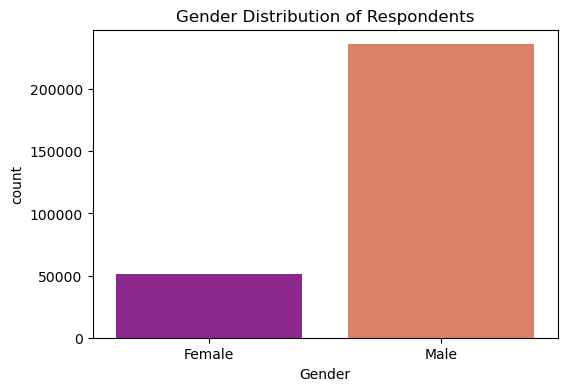

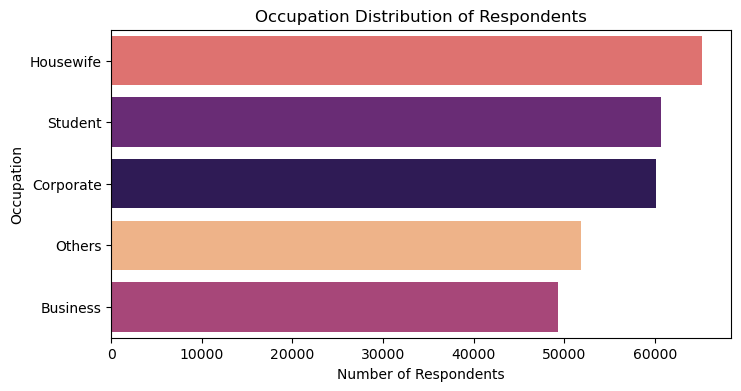

In [71]:
# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df, palette='plasma',hue='Gender',legend=False)
plt.title('Gender Distribution of Respondents')
plt.show()

# Occupation Distribution
plt.figure(figsize=(8,4))
sns.countplot(y='Occupation', data=df, palette='magma', 
              order=df['Occupation'].value_counts().index,hue='Occupation',legend=False)
plt.title('Occupation Distribution of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Occupation')
plt.show()

In [72]:
df_eng = df.copy()

ordinal_map = {
    'Growing_Stress':{'No':0,'Maybe':1,'Yes': 2},
    'Changes_Habits':{'No':0,'Maybe':1,'Yes': 2},
    'Mood_Swings':{'Low':0,'Medium':1,'High': 2},
    'Coping_Struggles':{'No':0,'Yes':1},
    'Work_Interest':{'No':0,'Maybe':1,'Yes': 2},
    'Social_Weakness':{'No':0,'Maybe':1,'Yes': 2}
}

for col,mapping in ordinal_map.items():
    df_eng[col]=df_eng[col].map(mapping)

df_eng['StressImpactScore']=df_eng['Growing_Stress']+df_eng['Changes_Habits']+df_eng['Mood_Swings']

df_eng['BehavioralStruggleScore']=df_eng['Coping_Struggles']+(2-df_eng['Work_Interest'])+df_eng['Social_Weakness']

print("--- Newly Engineered Features ---")
display(df_eng[['StressImpactScore','BehavioralStruggleScore']].head())

--- Newly Engineered Features ---


,StressImpactScore,BehavioralStruggleScore
3,3,4
4,3,4
5,3,4
6,3,4
7,3,4


##### Interpretation:
- By engineering these features, we now have single metrics that represent complex concepts. StressImpactScore gives a simple measure of overall stress manifestation, while BehavioralStruggleScore quantifies functional impairment.

C:\Users\mahes\AppData\Local\Temp\ipykernel_7628\980029856.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Did Not Seek Treatment', 'Sought Treatment'])
C:\Users\mahes\AppData\Local\Temp\ipykernel_7628\980029856.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Did Not Seek Treatment', 'Sought Treatment'])


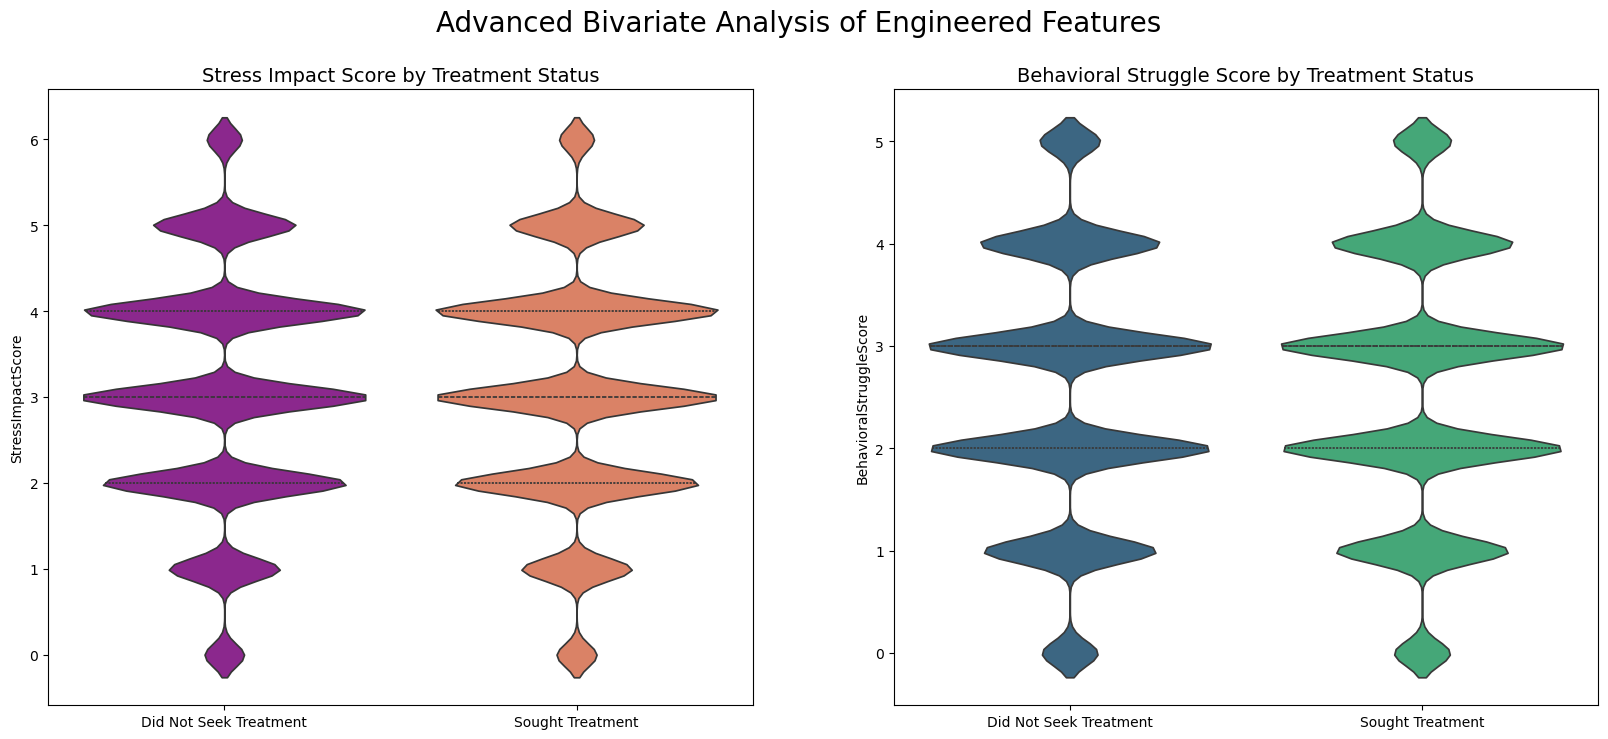

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Advanced Bivariate Analysis of Engineered Features', fontsize=20)

# StressImpactScore vs. Treatment
sns.violinplot(ax=axes[0],data=df_eng,x='treatment',y='StressImpactScore', 
               palette='plasma',inner='quartile',hue='treatment',legend=False)
axes[0].set_title('Stress Impact Score by Treatment Status', fontsize=14)
axes[0].set_xticklabels(['Did Not Seek Treatment', 'Sought Treatment'])
axes[0].set_xlabel('')

# BehavioralStruggleScore vs. Treatment
sns.violinplot(ax=axes[1],data=df_eng,x='treatment',y='BehavioralStruggleScore', 
               palette='viridis',inner='quartile',hue='treatment',legend=False)
axes[1].set_title('Behavioral Struggle Score by Treatment Status', fontsize=14)
axes[1].set_xticklabels(['Did Not Seek Treatment', 'Sought Treatment'])
axes[1].set_xlabel('')

plt.show()

##### Interpretation:
The violin plots vividly illustrate that both the StressImpactScore and BehavioralStruggleScore are not just higher on average for those who seek treatment, but their entire distributions are shifted upwards. The wider shape of the violins for the "Sought Treatment" group indicates a greater diversity of experiences within this population, while the density peaks are clearly centered at higher scores.

C:\Users\mahes\AppData\Local\Temp\ipykernel_7628\2028641859.py:3: FutureWarning: The provided callable <function mean at 0x000002154FA79260> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table=df_eng.pivot_table(values='treatment_binary',index='Occupation',


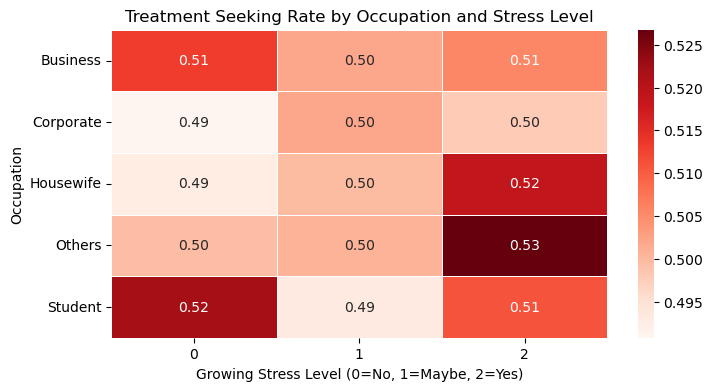

In [74]:
df_eng['treatment_binary']=df_eng['treatment'].map({'No':0,'Yes':1})

pivot_table=df_eng.pivot_table(values='treatment_binary',index='Occupation',
                               columns='Growing_Stress', aggfunc=np.mean)

plt.figure(figsize=(8,4))
sns.heatmap(pivot_table,annot=True,fmt='.2f',cmap='Reds',linewidths=.5)
plt.title('Treatment Seeking Rate by Occupation and Stress Level',fontsize=12)
plt.xlabel('Growing Stress Level (0=No, 1=Maybe, 2=Yes)')
plt.ylabel('Occupation')
plt.show()

### Statistical Hypothesis Testing - Validating Our Observations

Visualizations suggest strong relationships. We will now use statistical tests to provide rigorous, quantitative evidence for our key findings.
-   **Chi-Squared Test:** For the association between two categorical variables (`family_history` and `treatment`).
-   **T-Test:** To compare the means of our engineered continuous variable (`StressImpactScore`) between the two treatment groups.

In [75]:
# Chi-Squared Test
contingency_table=pd.crosstab(df_eng['family_history'],df_eng['treatment'])
chi2,p,_,_=chi2_contingency(contingency_table)
print(f"--- Chi-Squared Test for Family History ---")
print(f"Chi2 Statistic:{chi2:.2f}")
print(f"P-value:{p}")
if p<0.05:
    print("Result: The association is statistically significant. We reject the null hypothesis of independence.\n")
else:
    print("Result: The association is not statistically significant.\n")

# T-Test
sought_treatment_score=df_eng[df_eng['treatment']=='Yes']['StressImpactScore']
no_treatment_score=df_eng[df_eng['treatment']=='No']['StressImpactScore']

t_stat,p_val=ttest_ind(sought_treatment_score,no_treatment_score)
print(f"--- Independent T-Test for StressImpactScore ---")
print(f"T-statistic:{t_stat:.2f}")
print(f"P-value:{p_val}")
if p_val<0.05:
    print("Result: The difference in mean StressImpactScore between the two groups is statistically significant.")
else:
    print("Result: The difference in mean StressImpactScore is not statistically significant.")

--- Chi-Squared Test for Family History ---
Chi2 Statistic:39624.74
P-value:0.0
Result: The association is statistically significant. We reject the null hypothesis of independence.

--- Independent T-Test for StressImpactScore ---
T-statistic:2.59
P-value:0.009487118610155899
Result: The difference in mean StressImpactScore between the two groups is statistically significant.


### Dimensionality Reduction with PCA for Visualization

Can we "see" the separation between the treatment groups using all features combined? Principal Component Analysis (PCA) reduces our high-dimensional data into 2 "principal components" that capture the most variance. This allows us to visualize the overall data structure.